In [2]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
from qutip.qip.operations import rz, cz_gate
from tqdm import tqdm
from matplotlib.colors import LogNorm
import pytz, cmath, itertools
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
from joblib import Parallel, delayed
import scipy.sparse as ssp
from sympy import symbols
import utils_2Q_gate_zp as ut
import pandas as pd
import scipy as sp
from multiprocessing import Pool
import qutip as qt
import multiprocessing as mp
import scqubits as scq
from sympy import symbols
import scipy.sparse as ssp
from datetime import datetime
import ham_data as hd

# Coupled zero pi

In [ ]:
t1_other = 50 # μs
gamma_decay_other =  1 / 1e3 / t1_other
gamma_dephase_other = 1 / 1e3 / t1_other
state_mid = 8
idx_2 = 2
idx_8 = 5

folder = f'../../data/3ncut_two_zeropi/truc1=500/'
# n_theta0 = np.load(folder+'n_theta0.npy')
# n_theta1 = np.load(folder+'n_theta1.npy')
# eval0 = pd.read_csv(folder+ 'eval0.txt').to_numpy().flatten()
# eval1 = pd.read_csv(folder+ 'eval1.txt').to_numpy().flatten()
eval0_flux = pd.read_csv(folder+ 'eval0_flux=0.001.txt').to_numpy().flatten()
eval1_flux = pd.read_csv(folder+ 'eval1_flux=0.001.txt').to_numpy().flatten()

In [ ]:
folder_load = '../../data/_truc_3000'
# folder_load = '../data/_truc_3000'
eval0,eval1,n_theta0,n_theta1 = hd.load_1q_data_for_2q(folder_load)

In [6]:
len(eval0)
np.shape(n_theta0)

(300, 300)

In [11]:
dim = 10
qt.Qobj(n_theta1[:dim, :dim])

Quantum object: dims = [[10], [10]], shape = (10, 10), type = oper, isherm = True
Qobj data =
[[ 0.          1.31207974  0.          0.          0.          0.00762752
   0.          0.         -0.04614325  0.        ]
 [ 1.31207974  0.          0.01883263  0.         -1.79944351  0.
   0.          0.          0.         -0.08035055]
 [ 0.          0.01883263  0.          0.          0.         -1.28549462
   0.          0.         -0.11683501  0.        ]
 [ 0.          0.          0.          0.          0.          0.
  -1.29193251  0.          0.          0.        ]
 [ 0.         -1.79944351  0.          0.          0.         -0.24261693
   0.          0.          2.08797877  0.        ]
 [ 0.00762752  0.         -1.28549462  0.         -0.24261693  0.
   0.          0.          0.          1.54157623]
 [ 0.          0.          0.         -1.29193251  0.          0.
   0.         -0.06403298  0.          0.        ]
 [ 0.          0.          0.          0.          0.          

In [5]:
dim = 10
qt.Qobj(n_theta0[:dim, :dim])

Quantum object: dims = [[10], [10]], shape = (10, 10), type = oper, isherm = True
Qobj data =
[[ 0.         -1.35218494  0.          0.          0.          0.00440778
   0.          0.         -0.04375543  0.        ]
 [-1.35218494  0.         -0.01039451  0.          1.85992081  0.
   0.          0.          0.          0.05480165]
 [ 0.         -0.01039451  0.          0.          0.         -1.33423477
   0.          0.         -0.06549022  0.        ]
 [ 0.          0.          0.          0.          0.          0.
   1.33640594  0.          0.          0.        ]
 [ 0.          1.85992081  0.          0.          0.         -0.14287071
   0.          0.          2.18191516  0.        ]
 [ 0.00440778  0.         -1.33423477  0.         -0.14287071  0.
   0.          0.          0.          1.71935551]
 [ 0.          0.          0.          1.33640594  0.          0.
   0.         -0.04130832  0.          0.        ]
 [ 0.          0.          0.          0.          0.          

In [6]:
truc1, truc_tot, charge_pick = 300, 1000, True
folder = f'../../data/3ncut_two_zeropi/truc1={truc1}_truc2={truc_tot}_pick={charge_pick}/'
hspace_0 = pd.read_csv(folder+ 'hspace_0.txt').to_numpy().flatten().tolist()
hspace_1 = pd.read_csv(folder+ 'hspace_1.txt').to_numpy().flatten().tolist()
hspace_full = pd.read_csv(folder+ 'hspace_full.txt').to_numpy().flatten().tolist()
print('len(hspace_0)=', len(hspace_0))
print('len(hspace_1)=', len(hspace_1))
# print('hspace_0=', hspace_0)
# print('hspace_1=', hspace_1)

len(hspace_0)= 154
len(hspace_1)= 155


### $T_1$

$\gamma_{ll'} = \Gamma | \bra{l} n_\theta \ket{l'} |^2 = 1/ T_1  $ ( $T_1$ is intrawell decay time )

$\gamma_{07} = \Gamma_{07} | \bra{0} n_\theta \ket{7} |^2 = 1 / (2\times 10^{-6})   $

In [ ]:
drive_qubit_0 = True
hspace = hspace_0 if drive_qubit_0 else hspace_1
n_theta = n_theta0 if drive_qubit_0 else n_theta1

gamma_decay_48 = []
gamma_decay_08 = []
gamma_decay_28 = []
Gamma_08 = gamma_decay_other / (n_theta[0,8]**2)
Gamma_28 = gamma_decay_other / (n_theta[2,8]**2)
Gamma_48 = gamma_decay_other / (n_theta[4,8]**2)
for i in hspace:
    gamma_decay_08.append(Gamma_08* n_theta[0, i]**2)
    gamma_decay_28.append(Gamma_28* n_theta[0, i]**2)
    gamma_decay_48.append(Gamma_48* n_theta[0, i]**2)
# if np.all(np.imag(gamma_decay_08)==0) and np.all(np.imag(gamma_decay_28)==0):
decay_08_qubit0 = np.real(gamma_decay_08)
decay_28_qubit0 = np.real(gamma_decay_28)
decay_48_qubit0 = np.real(gamma_decay_48)
print(f'Gamma_08={Gamma_08}, Gamma_28={Gamma_28}, Gamma_48={Gamma_48}')
decay_48_qubit0

Gamma_08=(0.010446386339359272+0j), Gamma_28=(0.0046631254255608025+0j), Gamma_48=(4.2010154243212975e-06+0j)


array([0.00000000e+00, 7.68115388e-06, 0.00000000e+00, 0.00000000e+00,
       8.16195312e-11, 8.04300222e-09, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.18869695e-11, 2.14981413e-11, 1.42373390e-11,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.04774231e-08,
       0.00000000e+00, 0.00000000e+00, 1.58810601e-09, 0.00000000e+00,
       2.60390801e-09, 0.00000000e+00, 2.78778631e-11, 1.27659663e-11,
       0.00000000e+00, 4.48366456e-10, 0.00000000e+00, 2.03623807e-10,
       0.00000000e+00, 0.00000000e+00, 5.69734880e-11, 0.00000000e+00,
       1.98756216e-11, 0.00000000e+00, 0.00000000e+00, 4.39999135e-13,
       0.00000000e+00, 3.18645199e-11, 0.00000000e+00, 4.12621887e-13,
       0.00000000e+00, 1.90030764e-11, 0.00000000e+00, 4.84495379e-11,
       0.00000000e+00, 4.93450180e-11, 0.00000000e+00, 5.31313750e-13,
       0.00000000e+00, 0.00000000e+00, 1.90792779e-13, 0.00000000e+00,
       4.46274399e-12, 0.00000000e+00, 0.00000000e+00, 1.68385277e-11,
      

In [ ]:
drive_qubit_0 = False
hspace = hspace_0 if drive_qubit_0 else hspace_1
n_theta = n_theta0 if drive_qubit_0 else n_theta1

gamma_decay_48 = []
gamma_decay_08 = []
gamma_decay_28 = []
Gamma_08 = gamma_decay_other / (n_theta[0,8]**2)
Gamma_28 = gamma_decay_other / (n_theta[2,8]**2)
Gamma_48 = gamma_decay_other / (n_theta[4,8]**2)
for i in hspace:
    gamma_decay_08.append(Gamma_08* n_theta[0, i]**2)
    gamma_decay_28.append(Gamma_28* n_theta[0, i]**2)
    gamma_decay_48.append(Gamma_48* n_theta[0, i]**2)
# if np.all(np.imag(gamma_decay_08)==0) and np.all(np.imag(gamma_decay_28)==0):
decay_08_qubit1 = np.real(gamma_decay_08)
decay_28_qubit1 = np.real(gamma_decay_28)
decay_48_qubit1 = np.real(gamma_decay_48)
print(f'Gamma_08={Gamma_08}, Gamma_28={Gamma_28}, Gamma_48={Gamma_48}')
decay_48_qubit1

Gamma_08=(0.009393201438781239+0j), Gamma_28=(0.001465156430511143+0j), Gamma_48=(4.587518604574894e-06+0j)


array([0.00000000e+00, 7.68115388e-06, 0.00000000e+00, 0.00000000e+00,
       8.16195312e-11, 8.04300222e-09, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.18869695e-11, 2.14981413e-11, 1.42373390e-11,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.04774231e-08,
       0.00000000e+00, 0.00000000e+00, 1.58810601e-09, 0.00000000e+00,
       2.60390801e-09, 0.00000000e+00, 2.78778631e-11, 1.27659663e-11,
       0.00000000e+00, 4.48366456e-10, 0.00000000e+00, 2.03623807e-10,
       0.00000000e+00, 0.00000000e+00, 5.69734880e-11, 0.00000000e+00,
       1.98756216e-11, 0.00000000e+00, 0.00000000e+00, 4.39999135e-13,
       0.00000000e+00, 3.18645199e-11, 0.00000000e+00, 4.12621887e-13,
       0.00000000e+00, 1.90030764e-11, 0.00000000e+00, 4.84495379e-11,
       0.00000000e+00, 4.93450180e-11, 0.00000000e+00, 5.31313750e-13,
       0.00000000e+00, 0.00000000e+00, 1.90792779e-13, 0.00000000e+00,
       4.46274399e-12, 0.00000000e+00, 0.00000000e+00, 1.68385277e-11,
      

In [ ]:
=

### $T_\phi$

In [7]:
derivative_A = [np.abs(eval0_flux[i] - eval0[i]) / 0.001 for i in hspace_0]
derivative_B = [np.abs(eval1_flux[i] - eval1[i]) / 0.001 for i in hspace_1]
w_ir = 1e-9* 2 * np.pi # 1 Hz
t = 10e3 # 10 us = 10e3 ns
print(' derivative_07=', derivative_A[idx_8])
print('derivative_02=', derivative_A[idx_2])
print('derivative_27=', derivative_A[idx_8] - derivative_A[idx_2] )

 derivative_07= 0.0005518654537794987
derivative_02= 6.61711138022536
derivative_27= -6.6165595147715806


In [8]:
# ### Fix A with tphi=50us and 02
A0_02 = gamma_dephase_other / (derivative_A[idx_2] * np.sqrt(2 * np.abs(np.log(w_ir * t))))
A1_02 = gamma_dephase_other / (derivative_B[idx_2] * np.sqrt(2 * np.abs(np.log(w_ir * t))))
print(f'A0_02={A0_02}, A1_02={A1_02}')
# ### Fix A with tphi=50us and 08
A0_08 = gamma_dephase_other / (derivative_A[idx_8] * np.sqrt(2 * np.abs(np.log(w_ir * t))))
A1_08 = gamma_dephase_other / (derivative_B[idx_8] * np.sqrt(2 * np.abs(np.log(w_ir * t))))
print(f'A0_08={A0_08}, A1_08={A1_08}')

A0_02=6.871000496265792e-07, A1_02=7.294025349269678e-07
A0_08=0.00823863412105168, A1_08=0.00814230124209047


In [9]:
gamma_tphi_50us_02_qubit0 = A0_02 * np.array(derivative_A) * np.sqrt(2 * np.abs(np.log(w_ir * t)))
gamma_tphi_50us_02_qubit1 = A1_02 * np.array(derivative_B) * np.sqrt(2 * np.abs(np.log(w_ir * t)))
gamma_tphi_50us_02_qubit0

array([0.00000000e+00, 1.62198468e-10, 2.00000000e-05, 5.27725942e-10,
       1.52537320e-05, 1.66799506e-09, 3.06048767e-06, 1.07657820e-08,
       1.02571314e-05, 1.31297859e-06, 2.45989912e-07, 4.07618479e-07,
       9.49155085e-07, 3.52939414e-08, 2.43615872e-07, 5.71589543e-09,
       3.42165059e-05, 7.05117137e-08, 1.68650358e-07, 5.80664127e-08,
       2.03819354e-07, 2.87681195e-07, 1.63335564e-06, 1.01062463e-06,
       2.59930142e-07, 5.33391015e-09, 3.56411273e-07, 1.03497830e-07,
       9.56974482e-08, 7.19069547e-07, 9.98122623e-07, 5.43574076e-08,
       1.17656977e-07, 2.83345851e-06, 7.78194730e-07, 3.49629440e-08,
       6.13186810e-09, 4.62363948e-06, 3.14714022e-07, 2.31528650e-07,
       1.25585451e-06, 2.48302753e-06, 2.70233384e-08, 2.99743048e-07,
       4.22032345e-07, 7.41788419e-09, 7.94761034e-08, 8.67553316e-08,
       9.34959260e-08, 5.57985752e-07, 5.80721077e-07, 8.12301628e-07,
       6.16867389e-07, 1.40339813e-07, 4.58405204e-08, 9.95275742e-08,
      

In [10]:
A0 = 1e-6
A1 = 1e-6
gamma_tphi_1e6_qubit0 = A0 * np.array(derivative_A) * np.sqrt(2 * np.abs(np.log(w_ir * t)))
gamma_tphi_1e6_qubit1 = A1 * np.array(derivative_B) * np.sqrt(2 * np.abs(np.log(w_ir * t)))
gamma_tphi_1e6_qubit0

array([0.00000000e+00, 2.36062372e-10, 2.91078425e-05, 7.68048180e-10,
       2.22001614e-05, 2.42758687e-09, 4.45420965e-06, 1.56684343e-08,
       1.49281482e-05, 1.91089870e-06, 3.58011781e-07, 5.93244723e-07,
       1.38139283e-06, 5.13665243e-08, 3.54556621e-07, 8.31886918e-09,
       4.97984331e-05, 1.02622193e-07, 2.45452402e-07, 8.45093996e-08,
       2.96637082e-07, 4.18688945e-07, 2.37717293e-06, 1.47085512e-06,
       3.78300282e-07, 7.76293082e-09, 5.18718160e-07, 1.50629927e-07,
       1.39277312e-07, 1.04652816e-06, 1.45265980e-06, 7.91113428e-08,
       1.71237038e-07, 4.12379319e-06, 1.13257848e-06, 5.08847933e-08,
       8.92427253e-09, 6.72920847e-06, 4.58032308e-07, 3.36964973e-07,
       1.82776076e-06, 3.61377871e-06, 3.93295538e-08, 4.36243671e-07,
       6.14222551e-07, 1.07959302e-08, 1.15668895e-07, 1.26263026e-07,
       1.36073234e-07, 8.12088069e-07, 8.45176881e-07, 1.18221739e-06,
       8.97783939e-07, 2.04249458e-07, 6.67159323e-08, 1.44851647e-07,
      

In [ ]:
=

In [ ]:
data_0 = {
    'hspace'    : hspace_0,
    'tphi_1e6'  : gamma_tphi_1e6_qubit0,
    'tphi_02' : gamma_tphi_50us_02_qubit0,
    't1_50us_48': decay_48_qubit0,
}
qubit0 = pd.DataFrame(data_0)

data_1 = {
    'hspace'    : hspace_1,
    'tphi_1e6'  : gamma_tphi_1e6_qubit1,
    'tphi_02' : gamma_tphi_50us_02_qubit1,
    't1_50us_48': decay_48_qubit1,
}
qubit1 = pd.DataFrame(data_1)
folder = f'../../data/3ncut_two_zeropi/truc1=500/'
qubit0.to_csv(folder + 'data_gamma_qubit0.txt' , index=False)
qubit1.to_csv(folder + 'data_gamma_qubit1.txt' , index=False)


: 

### Save file

In [14]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
# folder = f'../../data/3ncut_two_zeropi/truc1=500/'
# qbt0 = np.column_stack((hspace_0, gamma_dephase_qubit0, decay_28_qubit0))
# df = pd.DataFrame(qbt0, columns=['hspace', 'dephase' ,'decay'])
# df.to_csv(folder+'data_gamma_qubit0_t1_28_tphi_1e-6.txt' , index=False)
# qbt0 = np.column_stack((hspace_1, gamma_dephase_qubit1, decay_28_qubit1))
# df = pd.DataFrame(qbt0, columns=['hspace', 'dephase' ,'decay'])
# df.to_csv(folder+'data_gamma_qubit1_t1_28_tphi_1e-6.txt' , index=False)

In [ ]:
folder = f'../../data/3ncut_two_zeropi/truc1=500/'
gamma_0 = pd.read_csv(folder+ 'data_gamma_qubit0.txt')
gamma_1 = pd.read_csv(folder+ 'data_gamma_qubit1.txt')

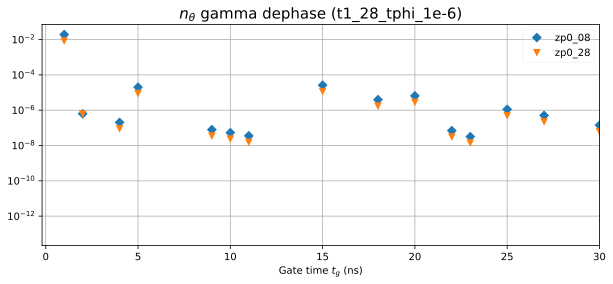

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
plt.plot(zp0['decay_2us_0'], 'D', label=r'zp0_08')
plt.plot(zp0['decay_2us_2'], 'v', label=r'zp0_28')
plt.xlim(-0.2,30)
# plt.ylim(0,)
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'$n_\theta$ gamma dephase (t1_28_tphi_1e-6)', fontsize=15)
plt.grid()
legend = plt.legend( loc="best")
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

# Single zero pi

In [ ]:
folder = '../../data/3ncut_one_zeropi/'
eval_0 = scq.read(folder + f'zeropi_0_specdata_truc=1000_3ncut.h5').energy_table
n_theta0 = scq.read(folder + f'zeropi_0_n_theta_truc=1000_3ncut.h5').matrixelem_table
n_phi0 = scq.read(folder + f'zeropi_0_n_phi_truc=1000_3ncut.h5').matrixelem_table
eval_0 = eval_0 - eval_0[0]
eval_1 = scq.read(folder + f'zeropi_1_specdata_truc=1000_3ncut.h5').energy_table
n_theta1 = scq.read(folder + f'zeropi_1_n_theta_truc=1000_3ncut.h5').matrixelem_table
n_phi1 = scq.read(folder + f'zeropi_1_n_phi_truc=1000_3ncut.h5').matrixelem_table
eval_1 = eval_1 - eval_1[0]


In [ ]:
# truc1 = 300
# hspace_0 = [0, 2]
# hspace_1 = [0, 2]
# for s in hspace_0:
#     for i in range(truc1):
#         if np.abs(n_theta0[s, i]) > 0.001 and i not in hspace_0:
#             hspace_0.append(i)
# hspace_0.sort()
# for s in hspace_1:
#     for i in range(truc1):
#         if np.abs(n_theta1[s, i]) > 0.001 and i not in hspace_1:
#             hspace_1.append(i)
# hspace_1.sort()

# print(len(hspace_0), len(hspace_1))
# for i in range(0, len(hspace_0), 10):
#     print(', '.join(map(str, np.round(hspace_0[i:i+10], 8))), ',')
# for i in range(0, len(hspace_1), 10):
#     print(', '.join(map(str, np.round(hspace_1[i:i+10], 8))), ',')

157 157
0, 1, 2, 4, 5, 7, 8, 11, 12, 16 ,
17, 18, 21, 23, 25, 27, 30, 31, 32, 33 ,
37, 38, 40, 41, 42, 45, 46, 47, 48, 51 ,
52, 56, 59, 62, 63, 64, 65, 67, 72, 73 ,
74, 76, 78, 79, 82, 83, 85, 87, 88, 90 ,
92, 93, 96, 97, 98, 102, 103, 106, 107, 112 ,
114, 118, 119, 120, 121, 122, 123, 124, 127, 128 ,
131, 132, 133, 134, 137, 138, 142, 143, 150, 151 ,
154, 155, 156, 157, 158, 161, 162, 163, 166, 170 ,
171, 174, 175, 176, 177, 179, 180, 186, 187, 188 ,
191, 192, 195, 196, 199, 202, 203, 206, 207, 208 ,
210, 213, 214, 218, 219, 220, 221, 222, 225, 226 ,
230, 231, 232, 236, 237, 238, 242, 243, 246, 247 ,
248, 251, 252, 258, 259, 260, 262, 263, 264, 270 ,
271, 274, 275, 279, 280, 281, 283, 284, 285, 288 ,
289, 290, 294, 296, 297, 298, 299 ,
0, 1, 2, 4, 5, 7, 8, 11, 13, 16 ,
17, 18, 20, 23, 25, 27, 30, 31, 32, 33 ,
36, 38, 40, 41, 42, 44, 45, 47, 48, 53 ,
54, 56, 59, 60, 63, 64, 65, 66, 70, 73 ,
74, 75, 79, 80, 82, 83, 84, 88, 89, 90 ,
92, 93, 96, 97, 98, 102, 105, 106, 107, 112 ,
114, 118,

In [ ]:
hspace_0 = [
0, 1, 2, 4, 5, 7, 8, 11, 12, 16 ,
17, 18, 21, 23, 25, 27, 30, 31, 32, 33 ,
37, 38, 40, 41, 42, 45, 46, 47, 48, 51 ,
52, 56, 59, 62, 63, 64, 65, 67, 72, 73 ,
74, 76, 78, 79, 82, 83, 85, 87, 88, 90 ,
92, 93, 96, 97, 98, 102, 103, 106, 107, 112 ,
114, 118, 119, 120, 121, 122, 123, 124, 127, 128 ,
131, 132, 133, 134, 137, 138, 142, 143, 150, 151 ,
154, 155, 156, 157, 158, 161, 162, 163, 166, 170 ,
171, 174, 175, 176, 177, 179, 180, 186, 187, 188 ,
191, 192, 195, 196, 199, 202, 203, 206, 207, 208 ,
210, 213, 214, 218, 219, 220, 221, 222, 225, 226 ,
230, 231, 232, 236, 237, 238, 242, 243, 246, 247 ,
248, 251, 252, 258, 259, 260, 262, 263, 264, 270 ,
271, 274, 275, 279, 280, 281, 283, 284, 285, 288 ,
289, 290, 294, 296, 297, 298, 299 ,
]
hspace_1 = [
0, 1, 2, 4, 5, 7, 8, 11, 13, 16 ,
17, 18, 20, 23, 25, 27, 30, 31, 32, 33 ,
36, 38, 40, 41, 42, 44, 45, 47, 48, 53 ,
54, 56, 59, 60, 63, 64, 65, 66, 70, 73 ,
74, 75, 79, 80, 82, 83, 84, 88, 89, 90 ,
92, 93, 96, 97, 98, 102, 105, 106, 107, 112 ,
114, 118, 119, 120, 121, 122, 123, 124, 127, 128 ,
131, 132, 133, 134, 138, 139, 141, 142, 150, 151 ,
154, 155, 156, 157, 158, 161, 164, 165, 166, 170 ,
171, 174, 175, 176, 177, 179, 180, 186, 187, 188 ,
189, 190, 195, 196, 199, 202, 203, 206, 207, 208 ,
212, 213, 214, 217, 219, 220, 221, 222, 225, 226 ,
230, 231, 232, 236, 237, 238, 242, 243, 244, 245 ,
248, 251, 252, 258, 259, 260, 262, 263, 264, 270 ,
273, 274, 275, 276, 277, 279, 283, 284, 285, 288 ,
289, 290, 295, 296, 297, 298, 299 ,
]

In [ ]:
folder1 = '../../data/3ncut_one_zeropi/'
zp0 = pd.read_csv( folder1 + 'zeropi_0_eval.txt')
zp1 = pd.read_csv( folder1 + 'zeropi_1_eval.txt')
derivative_A = [np.abs(zp0['eval_flux=0.001'][i] - zp0['eval_flux=0'][i]) / 0.001 for i in hspace_0]
derivative_B = [np.abs(zp1['eval_flux=0.001'][i] - zp1['eval_flux=0'][i]) / 0.001 for i in hspace_1]

w_ir = 1e-9* 2 * np.pi # 1 Hz
t = 10e3 # 10 us = 10e3 ns
A0 = 1e-6
A1 = 1e-6
gamma_tphi_1e6_qubit0 = A0 * np.array(derivative_A) * np.sqrt(2 * np.abs(np.log(w_ir * t)))
gamma_tphi_1e6_qubit1 = A1 * np.array(derivative_B) * np.sqrt(2 * np.abs(np.log(w_ir * t)))

print( 'gamma_dephase_qubit0=' ,gamma_tphi_1e6_qubit0.tolist())
print( '\ngamma_dephase_qubit1=' ,gamma_tphi_1e6_qubit1.tolist())

gamma_dephase_qubit0= [0.0, 3.205558446426136e-10, 1e-05, 1.1908375680424673e-09, 2.482262153125313e-06, 8.010444411678562e-10, 4.882066742575772e-07, 2.4379974092560418e-08, 1.0006582262103586e-06, 2.0676554106138076e-07, 2.651647545565418e-10, 2.698216643016875e-07, 1.4534141884145369e-07, 1.2450058321902464e-05, 6.081310028493021e-07, 1.990009147861666e-07, 1.0681908617403839e-06, 1.3214896356588352e-07, 8.074833284440567e-08, 2.604431255123769e-08, 7.160737996704374e-07, 2.8437358702639297e-08, 3.314617478195063e-07, 2.5775075889618824e-08, 1.0240786719294486e-08, 8.692166152473113e-07, 1.2150991257835336e-07, 1.065250312425472e-07, 3.9102457797778746e-07, 2.282083263778189e-07, 1.91960935923803e-07, 4.725347240899856e-08, 1.2323393775597673e-07, 1.5199617640310262e-06, 2.3725589211170067e-07, 9.536039822543888e-08, 1.794565428857527e-07, 1.1852983726113432e-06, 4.473615406482101e-07, 4.525859404360967e-07, 6.320426060011908e-08, 9.998565080095594e-09, 1.8189309071747355e-06, 4.255